# Factory Energy Report
Analysis of energy use, operating cost and temperature for 10 industrial machines.

**Author:** Ayush Ramtekkar  
**Tools:** Python, pandas, matplotlib  
**Assumptions:** electricity price 0.35 EUR/kWh, 365 operating days per year

## 1. Setup and data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("factory.csv")
df["daily_energy_kwh"] = df["power_kw"] * df["hours"]
df["yearly_cost_eur"] = df["daily_energy_kwh"] * 0.35 * 365
df

,machine,type,power_kw,hours,temp_c,daily_energy_kwh,yearly_cost_eur
0,Compressor A,compressor,7.5,8,95,60.0,7665.000
1,Pump B,pump,1.5,10,60,15.0,1916.250
2,Fan C,fan,0.1,5,20,0.5,63.875
3,Drill D,drill,0.5,8,50,4.0,511.000
4,Oven E,oven,4.0,6,88,24.0,3066.000
5,Chiller F,chiller,3.2,12,92,38.4,4905.600
6,Pump G,pump,2.2,16,71,35.2,4496.800
7,Fan H,fan,0.3,24,35,7.2,919.800
8,Compressor I,compressor,5.5,10,83,55.0,7026.250
9,Oven J,oven,6.0,4,97,24.0,3066.000


In [2]:
print(f"Machines analysed: {len(df)}")
print(f"Total yearly cost: {df['yearly_cost_eur'].sum():,.2f} EUR")

Machines analysed: 10
Total yearly cost: 33,636.57 EUR


## 2. Cost per machine type

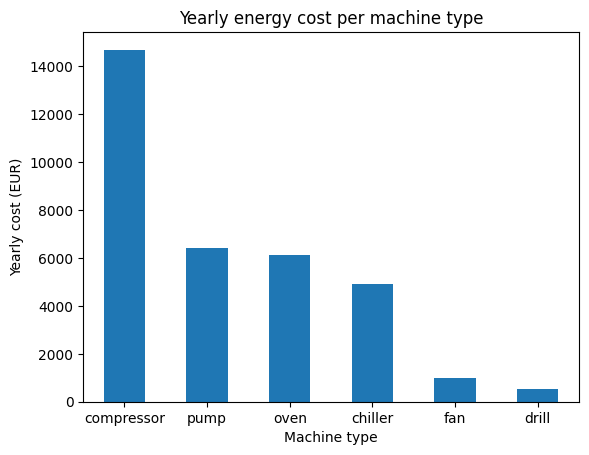

In [3]:
cost_by_type = df.groupby("type")["yearly_cost_eur"].sum().sort_values(ascending=False)
cost_by_type.plot(kind="bar")
plt.title("Yearly energy cost per machine type")
plt.xlabel("Machine type")
plt.ylabel("Yearly cost (EUR)")
plt.xticks(rotation=0)
plt.savefig("cost_by_type.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** The most expensive machine is Compressor A at 7,665 EUR/year. The two compressors together cost 14,691 EUR per year, about 44% of the factory's total energy cost (33,636 EUR), even though they are only 2 of 10 machines.

## 3. Cost per machine

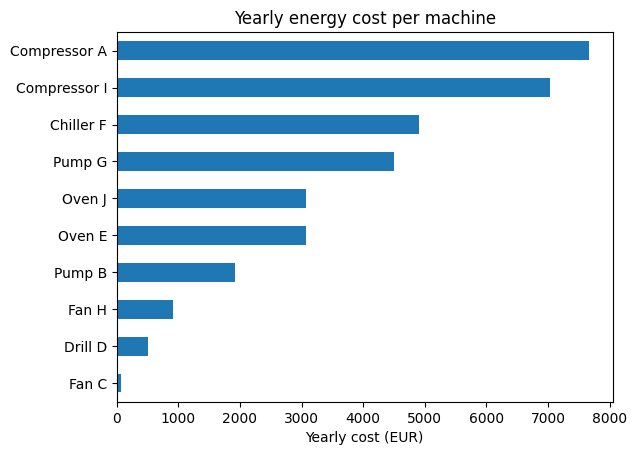

In [4]:
df.sort_values("yearly_cost_eur").plot(kind="barh", x="machine", y="yearly_cost_eur", legend=False)
plt.title("Yearly energy cost per machine")
plt.xlabel("Yearly cost (EUR)")
plt.ylabel("")
plt.show()

## 4. Operating temperature

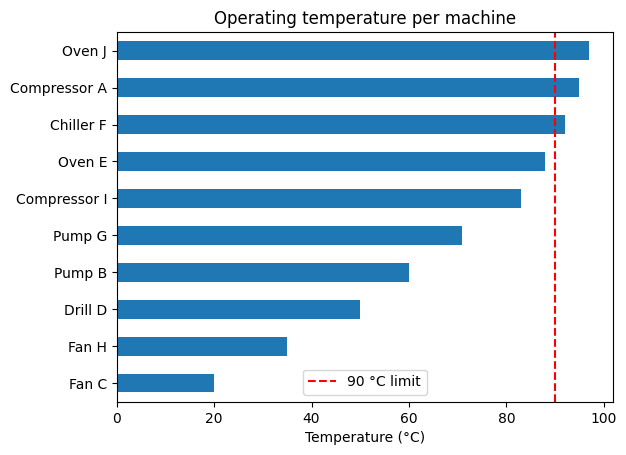

In [5]:
df.sort_values("temp_c").plot(kind="barh", x="machine", y="temp_c", legend=False)
limit = plt.axvline(90, color="red", linestyle="--", label="90 °C limit")
plt.title("Operating temperature per machine")
plt.xlabel("Temperature (°C)")
plt.ylabel("")
plt.legend(handles=[limit])
plt.savefig("temperature_per_machine.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** 3 machines run above the 90 °C limit: Oven J (97 °C), Compressor A (95 °C) and Chiller F (92 °C). Compressor I (83 °C) and Oven E (88 °C) are close to the limit and should be monitored.

## 5. Monthly energy use

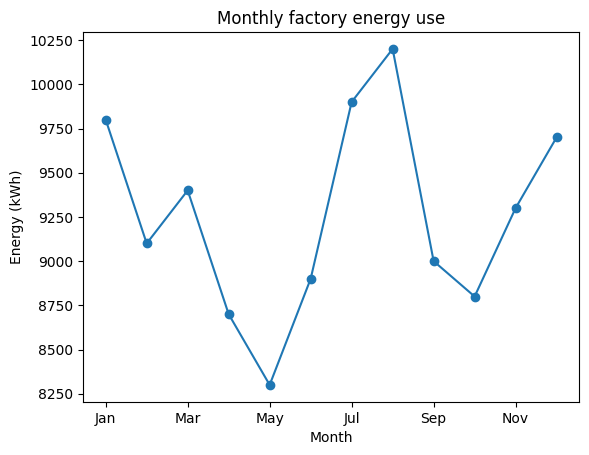

In [6]:
monthly = pd.DataFrame({
    "month": ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
    "energy_kwh": [9800, 9100, 9400, 8700, 8300, 8900, 9900, 10200, 9000, 8800, 9300, 9700]
})

monthly.plot(kind="line", x="month", y="energy_kwh", marker="o", legend=False)
plt.title("Monthly factory energy use")
plt.xlabel("Month")
plt.ylabel("Energy (kWh)")
plt.show()

**Insight:** Energy use peaks in August (10,200 kWh) and is lowest in May (8,300 kWh). The pattern is U-shaped: higher in summer due to cooling demand (chiller) and in winter due to heating, lowest in mild spring and autumn months.

## Recommendations

1. **Check overheating machines first:** Oven J, Compressor A and Chiller F run above 90 °C, which increases the risk of breakdowns.
2. **Focus energy savings on compressors:** they are 44% of total cost, so even a 10% efficiency gain would save about 1,470 EUR per year.
3. **Plan maintenance shutdowns in May or October:** these are the lowest-energy months, so production and cooling/heating are least affected.